In [1]:
import pandas as pd
conditions1 = pd.read_csv("data/GDSC1Log2ViabilityConditions.csv")
conditions2 = pd.read_csv("data/GDSC2Log2ViabilityConditions.csv")
auc1 = pd.read_csv("data/GDSC1AUCMatrix.csv",index_col=0)
auc2 = pd.read_csv("data/GDSC2AUCMatrix.csv",index_col=0)

In [2]:
olaparib1_info = conditions1[conditions1["CompoundName"].str.upper() == "OLAPARIB"]
print(olaparib1_info[["CompoundName","SampleID","CompoundID"]].drop_duplicates())
olaparib2_info = conditions2[conditions2["CompoundName"].str.upper() == "OLAPARIB"]
print(olaparib2_info[["CompoundName","SampleID","CompoundID"]].drop_duplicates())

     CompoundName    SampleID  CompoundID
7828     OLAPARIB  GDSC1:1495  DPC-004744
      CompoundName    SampleID  CompoundID
69201     OLAPARIB  GDSC2:1017  DPC-004744


In [3]:
target_id1 = "DPC-004744"
matches1 = [c for c in auc1.columns if target_id1 in str(c)]
print(matches1)
target_id2 = "DPC-004744"
matches2 = [c for c in auc2.columns if target_id2 in str(c)]
print(matches2)

['DPC-004744']
['DPC-004744']


In [4]:
olaparib_values1 = auc1[matches1[0]].dropna()
olaparib_values2 = auc2[matches2[0]].dropna()
print(f"Total cell lines with Olaparib data (GDSC1): {len(olaparib_values1)}")
print(f"Total cell lines with Olaparib data (GDSC2): {len(olaparib_values2)}")
print(olaparib_values1.describe())

Total cell lines with Olaparib data (GDSC1): 879
Total cell lines with Olaparib data (GDSC2): 944
count    879.000000
mean       0.924584
std        0.077692
min        0.407111
25%        0.891003
50%        0.939235
75%        0.985516
max        1.000000
Name: DPC-004744, dtype: float64


In [5]:
print(olaparib_values2.describe())

count    944.000000
mean       0.927223
std        0.052482
min        0.664897
25%        0.902797
50%        0.935165
75%        0.962145
max        1.000000
Name: DPC-004744, dtype: float64


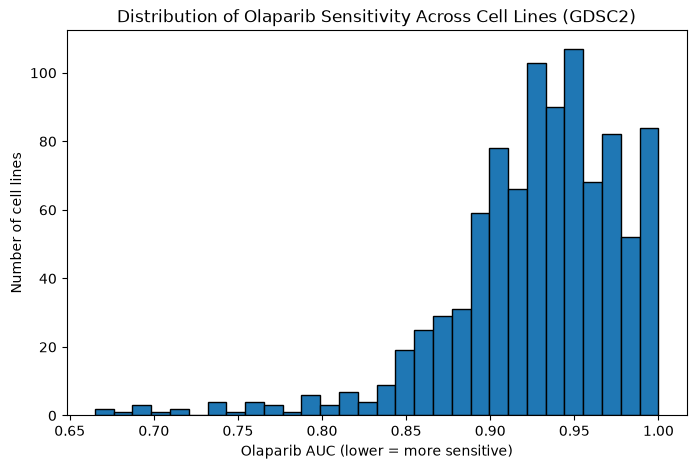

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(olaparib_values2, bins=30, edgecolor='black')
plt.xlabel("Olaparib AUC (lower = more sensitive)")
plt.ylabel("Number of cell lines")
plt.title("Distribution of Olaparib Sensitivity Across Cell Lines (GDSC2)")
plt.show()

In [7]:
expression = pd.read_csv("data/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv", index_col=0)

In [8]:
mutations = pd.read_csv("data/OmicsSomaticMutationsMatrixDamaging.csv", index_col=0)

In [9]:
metadata = pd.read_csv("data/Model.csv")

In [10]:
print("Expression:", expression.shape)

Expression: (1775, 19220)


In [11]:
print("Mutations:", mutations.shape)

Mutations: (3044, 19583)


In [12]:
print("Response (Olaparib, GDSC2):", len(olaparib_values2))

Response (Olaparib, GDSC2): 944


In [13]:
print(" index sample:", olaparib_values2.index[:5].tolist())

 index sample: ['ACH-000001', 'ACH-000002', 'ACH-000004', 'ACH-000006', 'ACH-000007']


In [14]:
print("Metadata columns:", metadata.columns.tolist()[:10])

Metadata columns: ['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures']


In [15]:
print(metadata.head(3))

      ModelID  PatientID CellLineName StrippedCellLineName DepmapModelType  \
0  ACH-000001  PT-gj46wT  NIH:OVCAR-3            NIHOVCAR3           HGSOC   
1  ACH-000002  PT-5qa3uk        HL-60                 HL60          AMLMRC   
2  ACH-000003  PT-puKIyc        CACO2                CACO2            COAD   

        OncotreeLineage     OncotreePrimaryDisease  \
0  Ovary/Fallopian Tube   Ovarian Epithelial Tumor   
1               Myeloid     Acute Myeloid Leukemia   
2                 Bowel  Colorectal Adenocarcinoma   

                           OncotreeSubtype OncotreeCode  \
0         High-Grade Serous Ovarian Cancer        HGSOC   
1  AML with Myelodysplasia-Related Changes       AMLMRC   
2                     Colon Adenocarcinoma         COAD   

                              PatientSubtypeFeatures  ... PublicComments  \
0                                                NaN  ...            NaN   
1  TP53(del), CDKN2A and NRAS mutations [PubMed=2...  ...            NaN   
2    

In [16]:
print("Expression flag column values:")
print(expression['IsDefaultEntryForModel'].value_counts(dropna=False))
print("dtype:", expression['IsDefaultEntryForModel'].dtype)

print()
print("Mutations flag column values:")
print(mutations['IsDefaultEntryForModel'].value_counts(dropna=False))
print("dtype:", mutations['IsDefaultEntryForModel'].dtype)

Expression flag column values:
IsDefaultEntryForModel
Yes    1719
No       56
Name: count, dtype: int64
dtype: str

Mutations flag column values:
IsDefaultEntryForModel
Yes    1968
No     1076
Name: count, dtype: int64
dtype: str


In [17]:
print("Original expression shape:", expression.shape)

expression_clean = expression[expression['IsDefaultEntryForModel'] == 'Yes']
print("Rows after filtering to default entries:", expression_clean.shape)
print("Duplicate ModelIDs remaining:", expression_clean['ModelID'].duplicated().sum())

expression_clean = expression_clean.set_index('ModelID')
expression_clean = expression_clean.drop(columns=['SequencingID', 'ModelConditionID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel'])

print("Final expression_clean shape:", expression_clean.shape)
print(expression_clean.head(3))

Original expression shape: (1775, 19220)
Rows after filtering to default entries: (1719, 19220)
Duplicate ModelIDs remaining: 0
Final expression_clean shape: (1719, 19215)
            TSPAN6 (7105)  TNMD (64102)  DPM1 (8813)  SCYL3 (57147)  \
ModelID                                                               
ACH-001113       4.956577      0.000000     7.577648       3.179411   
ACH-001289       4.955015      0.617117     7.333933       2.782935   
ACH-001339       3.421952      0.000000     7.546069       2.615880   

            FIRRM (55732)  FGR (2268)  CFH (3075)  FUCA2 (2519)  GCLC (2729)  \
ModelID                                                                        
ACH-001113       4.765742    0.037483    1.510547      3.103039     6.697482   
ACH-001289       3.735371    0.000000    0.148922      3.855123     4.376707   
ACH-001339       4.476233    0.064571    1.397491      6.833915     3.980336   

            NFYA (4800)  ...  ATXN8 (724066)  SMIM42 (117981789)  \
Mod

In [18]:
print("Original mutations shape:", mutations.shape)

mutations_clean = mutations[mutations['IsDefaultEntryForModel'] == 'Yes']
print("Rows after filtering to default entries:", mutations_clean.shape)
print("Duplicate ModelIDs remaining:", mutations_clean['ModelID'].duplicated().sum())

mutations_clean = mutations_clean.set_index('ModelID')
mutations_clean = mutations_clean.drop(columns=['SequencingID', 'ModelConditionID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel'])

print("Final mutations_clean shape:", mutations_clean.shape)
print(mutations_clean.head(3))

Original mutations shape: (3044, 19583)
Rows after filtering to default entries: (1968, 19583)
Duplicate ModelIDs remaining: 0
Final mutations_clean shape: (1968, 19578)
            FAM87B (400728)  LINC02593 (100130417)  SAMD11 (148398)  \
ModelID                                                               
ACH-000062              1.0                    0.0              0.0   
ACH-002059              0.0                    1.0              0.0   
ACH-000402              0.0                    0.0              0.0   

            NOC2L (26155)  KLHL17 (339451)  PLEKHN1 (84069)  PERM1 (84808)  \
ModelID                                                                      
ACH-000062            0.0              0.0              0.0            0.0   
ACH-002059            0.0              0.0              0.0            0.0   
ACH-000402            0.0              0.0              0.0            0.0   

            HES4 (57801)  ISG15 (9636)  AGRN (375790)  ...  MT-ND5 (4540)  \
ModelI

In [19]:
expr_mut = expression_clean.join(mutations_clean, how='inner', lsuffix='_expr', rsuffix='_mut')
print("Expression alone:", expression_clean.shape)
print("Mutations alone:", mutations_clean.shape)
print("After expression + mutations inner join:", expr_mut.shape)

Expression alone: (1719, 19215)
Mutations alone: (1968, 19578)
After expression + mutations inner join: (1643, 38793)


In [20]:
merged = expr_mut.join(olaparib_values2.rename('AUC'), how='inner').copy()
print("Olaparib response alone:", len(olaparib_values2))
print("Final merged shape (expression + mutations + response):", merged.shape)

Olaparib response alone: 944
Final merged shape (expression + mutations + response): (696, 38794)


In [21]:
print()
print("Cell lines lost between expression+mutations and final merge:", len(expr_mut) - len(merged))


Cell lines lost between expression+mutations and final merge: 947


In [22]:
print("Merged shape:", merged.shape)
print()
print("Any NaN values remaining?", merged.isnull().values.any())
print("Total NaN cells:", merged.isnull().sum().sum())
print()
print("Data types (sample):")
print(merged.dtypes.value_counts())
print()
print(merged['AUC'].describe())

Merged shape: (696, 38794)

Any NaN values remaining? False
Total NaN cells: 0

Data types (sample):
float64    38794
Name: count, dtype: int64

count    696.000000
mean       0.928044
std        0.050320
min        0.684692
25%        0.903591
50%        0.935932
75%        0.961150
max        1.000000
Name: AUC, dtype: float64


In [23]:
cutoff = merged['AUC'].quantile(0.25)
print("AUC cutoff (25th percentile):", cutoff)

AUC cutoff (25th percentile): 0.9035910990342152


In [24]:
merged['sensitivity_label'] = merged['AUC'].apply(lambda x: 'sensitive' if x <= cutoff else 'resistant')

In [25]:
print(merged['sensitivity_label'].value_counts())
print(merged['sensitivity_label'].value_counts(normalize=True))

sensitivity_label
resistant    522
sensitive    174
Name: count, dtype: int64
sensitivity_label
resistant    0.75
sensitive    0.25
Name: proportion, dtype: float64


In [26]:
brca_cols = [c for c in merged.columns if 'BRCA1' in c or 'BRCA2' in c]
print(brca_cols)

['BRCA1 (672)_expr', 'BRCA2 (675)_expr', 'BRCA2 (675)_mut', 'BRCA1 (672)_mut']


In [27]:
# Encoding check: 0 = none, 1 = damaging with summed AF <= 0.95, 2 = summed AF > 0.95 (DepMap docs)
print(merged['BRCA1 (672)_mut'].value_counts())
print(merged['BRCA2 (675)_mut'].value_counts())

BRCA1 (672)_mut
0.0    685
1.0      7
2.0      4
Name: count, dtype: int64
BRCA2 (675)_mut
0.0    662
1.0     26
2.0      8
Name: count, dtype: int64


In [28]:
brca_max = merged[['BRCA1 (672)_mut', 'BRCA2 (675)_mut']].max(axis=1)

merged['BRCA_group'] = brca_max.map({
    0.0: 'no damaging mutation',
    1.0: 'damaging, AF<=0.95 (partial)',
    2.0: 'damaging, AF>0.95 (all copies)'
})

print(merged['BRCA_group'].value_counts())
print()
print(pd.crosstab(merged['BRCA_group'], merged['sensitivity_label']))
print()
print(pd.crosstab(merged['BRCA_group'], merged['sensitivity_label'], normalize='index'))
print()
print(merged.groupby('BRCA_group')['AUC'].describe())

BRCA_group
no damaging mutation              653
damaging, AF<=0.95 (partial)       31
damaging, AF>0.95 (all copies)     12
Name: count, dtype: int64

sensitivity_label               resistant  sensitive
BRCA_group                                          
damaging, AF<=0.95 (partial)           29          2
damaging, AF>0.95 (all copies)          9          3
no damaging mutation                  484        169

sensitivity_label               resistant  sensitive
BRCA_group                                          
damaging, AF<=0.95 (partial)     0.935484   0.064516
damaging, AF>0.95 (all copies)   0.750000   0.250000
no damaging mutation             0.741194   0.258806

                                count      mean       std       min       25%  \
BRCA_group                                                                      
damaging, AF<=0.95 (partial)     31.0  0.948304  0.035038  0.820975  0.933935   
damaging, AF>0.95 (all copies)   12.0  0.932216  0.036764  0.856403  0.91

In [29]:
from scipy.stats import fisher_exact

labels = merged[['AUC', 'sensitivity_label', 'BRCA_group']].copy()

wt = 'no damaging mutation'
groups = ['damaging, AF<=0.95 (partial)', 'damaging, AF>0.95 (all copies)']

for grp in groups:
    a = ((labels['BRCA_group'] == grp) & (labels['sensitivity_label'] == 'sensitive')).sum()
    b = ((labels['BRCA_group'] == grp) & (labels['sensitivity_label'] == 'resistant')).sum()
    c = ((labels['BRCA_group'] == wt) & (labels['sensitivity_label'] == 'sensitive')).sum()
    d = ((labels['BRCA_group'] == wt) & (labels['sensitivity_label'] == 'resistant')).sum()
    print(grp)
    print("  [[sens, resist] in group; [sens, resist] in wild-type]:", [[a, b], [c, d]])
    print("  odds ratio, p-value:", fisher_exact([[a, b], [c, d]]))

damaging, AF<=0.95 (partial)
  [[sens, resist] in group; [sens, resist] in wild-type]: [[np.int64(2), np.int64(29)], [np.int64(169), np.int64(484)]]
  odds ratio, p-value: SignificanceResult(statistic=np.float64(0.19751071209957152), pvalue=np.float64(0.01073674566856853))
damaging, AF>0.95 (all copies)
  [[sens, resist] in group; [sens, resist] in wild-type]: [[np.int64(3), np.int64(9)], [np.int64(169), np.int64(484)]]
  odds ratio, p-value: SignificanceResult(statistic=np.float64(0.9546351084812623), pvalue=1.0)


In [30]:
labels['lineage'] = metadata.set_index('ModelID')['OncotreeLineage'].reindex(labels.index)

print(pd.crosstab(labels['lineage'], labels['BRCA_group']))
print()
print(labels.groupby('lineage')['AUC'].agg(['count', 'mean']).sort_values('mean'))

BRCA_group                 damaging, AF<=0.95 (partial)  \
lineage                                                   
Adrenal Gland                                         0   
Biliary Tract                                         0   
Bladder/Urinary Tract                                 0   
Bone                                                  0   
Bowel                                                11   
Breast                                                3   
CNS/Brain                                             0   
Cervix                                                0   
Esophagus/Stomach                                     1   
Fibroblast                                            0   
Head and Neck                                         0   
Kidney                                                0   
Liver                                                 0   
Lung                                                  4   
Lymphoid                                              1 

In [31]:
import os

needed = ['AUC', 'sensitivity_label', 'BRCA_group']
missing = [c for c in needed if c not in merged.columns]
assert not missing, f"Run the label and BRCA_group cells first. Missing: {missing}"

os.makedirs("results", exist_ok=True)
merged[needed].to_csv("results/olaparib_labels.csv")
merged.to_csv("data/merged_expression_mutation_response.csv")
print("Saved:", merged.shape)

Saved: (696, 38796)


In [32]:
check = pd.read_csv("data/merged_expression_mutation_response.csv", index_col=0)
print(check.shape)
print(check[['sensitivity_label', 'BRCA_group']].head(3))

(696, 38796)
           sensitivity_label            BRCA_group
ModelID                                           
ACH-000242         sensitive  no damaging mutation
ACH-000708         resistant  no damaging mutation
ACH-000233         sensitive  no damaging mutation
